In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
cleaned_df = pd.read_excel("./data/clean_data.xlsx",sheet_name="Netflix")
genre_pivot_df = pd.read_excel("./data/clean_data.xlsx",sheet_name="Genre Pivot")
country_pivot_df = pd.read_excel("./data/clean_data.xlsx",sheet_name="Country Pivot")


## Répartition des contenus par classification d’âge (rating)

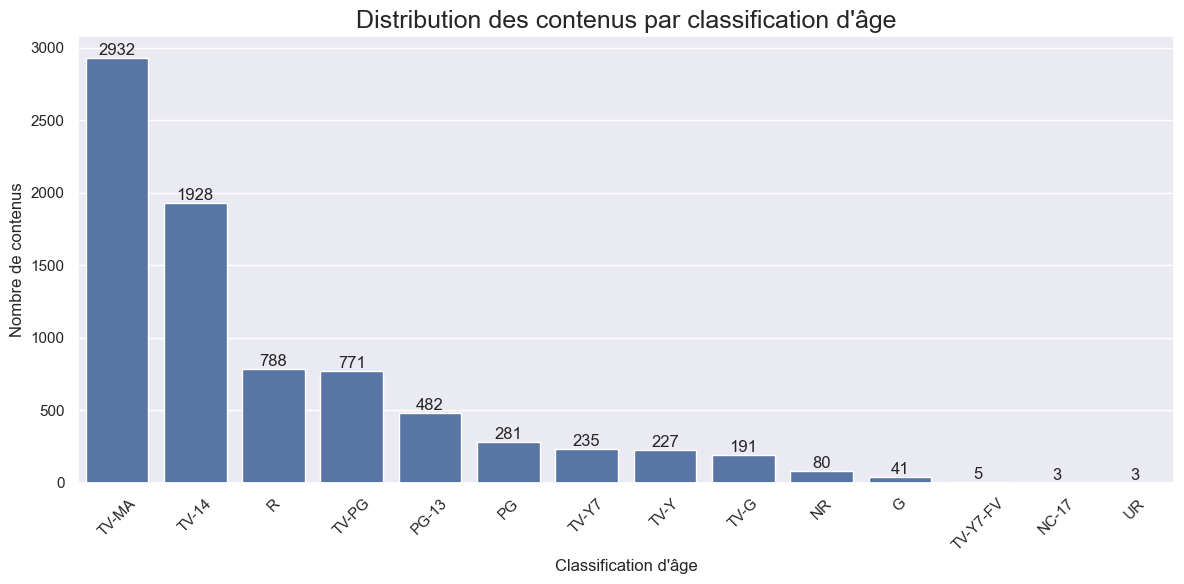

In [3]:
sns.set_theme()
plt.figure(figsize=(12,6))

rating_counts = cleaned_df["rating"].value_counts().sort_values(ascending=False)

ax = sns.barplot(
    x=rating_counts.index,
    y=rating_counts.values
)

plt.title("Distribution des contenus par classification d'âge", fontsize=18)
plt.xlabel("Classification d'âge")
plt.ylabel("Nombre de contenus")
plt.xticks(rotation=45)

for i, value in enumerate(rating_counts.values):
    ax.text(i, value + 20, str(value), ha='center')


del(rating_counts,ax,value)
plt.tight_layout()
plt.show()

#### La majorité du catalogue est classée TV-MA, indiquant une forte orientation vers un public adulte. Les contenus enfants représentent une part plus faible du catalogue global.

## Proportion de films vs séries (type)

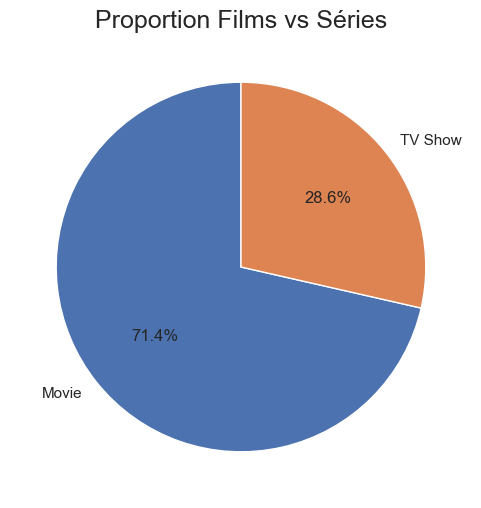

In [4]:
plt.figure(figsize=(6,6))

type_counts = cleaned_df["type"].value_counts()


plt.pie(
    type_counts.values,
    labels=type_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

del(type_counts)
plt.title("Proportion Films vs Séries", fontsize=18)
plt.show()

### Le catalogue est composé majoritairement de films (environ 71%), tandis que les séries représentent 29%. Netflix semble donc privilégier les films dans son offre globale.

## Nombre de contenus ajoutés chaque année (Year_added)

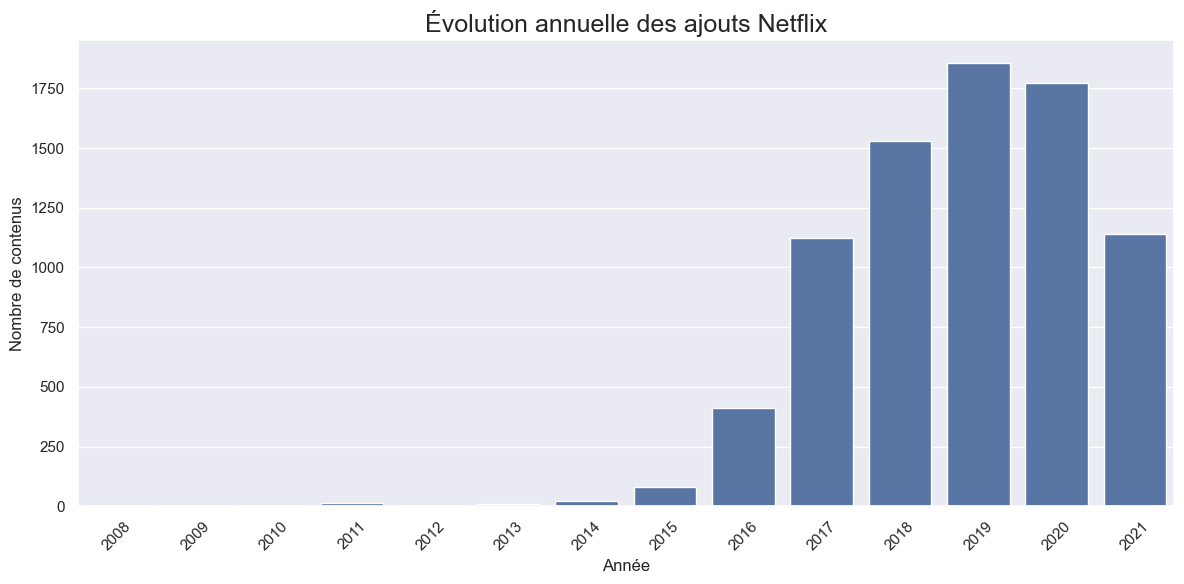

In [5]:
year_counts = cleaned_df["Year_added"].value_counts().sort_index()

plt.figure(figsize=(12,6))

sns.barplot(
    x=year_counts.index,
    y=year_counts.values
)

plt.title("Évolution annuelle des ajouts Netflix", fontsize=18)
plt.xlabel("Année")
plt.ylabel("Nombre de contenus")
plt.xticks(rotation=45)

del(year_counts)

plt.tight_layout()
plt.show()

### On observe une forte croissance des ajouts à partir de 2016, avec un pic en 2019, suivi d’un léger ralentissement après 2020.

## Évolution du catalogue : Films vs Séries par année

In [6]:
year_type_counts = (
    cleaned_df
    .groupby(["Year_added", "type"])
    .size()
    .reset_index(name="count")
)

year_type_counts

,Year_added,type,count
0,2008,Movie,1
1,2008,TV Show,1
2,2009,Movie,2
3,2010,Movie,1
4,2011,Movie,13
5,2012,Movie,3
6,2013,Movie,6
7,2013,TV Show,5
8,2014,Movie,19
9,2014,TV Show,5


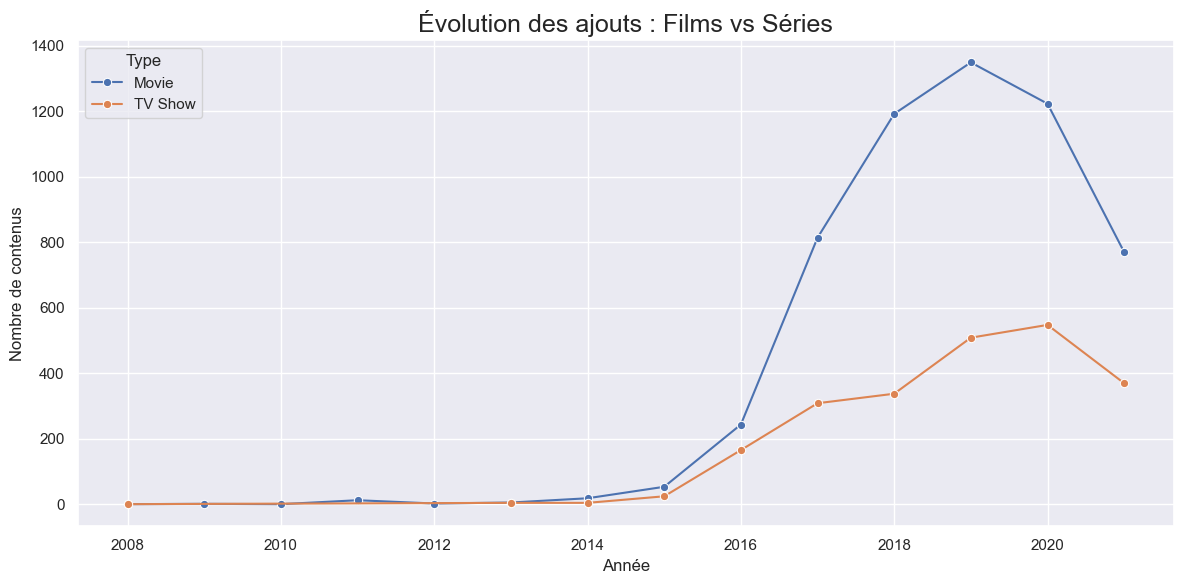

In [7]:
plt.figure(figsize=(12,6))

sns.lineplot(
    data=year_type_counts,
    x="Year_added",
    y="count",
    hue="type",
    marker="o"
)

plt.title("Évolution des ajouts : Films vs Séries", fontsize=18)
plt.xlabel("Année")
plt.ylabel("Nombre de contenus")
plt.legend(title="Type",loc="upper left")

del(year_type_counts)

plt.tight_layout()
plt.show()

### On observe une forte accélération des ajouts de séries à partir de 2016, ce qui correspond à la stratégie d’investissement massif de Netflix dans les productions originales.

## Nombre de productions par pays

In [8]:
top_countries = country_pivot_df.sort_values("count", ascending=False).head(15)
top_countries

,country,count
0,United States,3683
1,India,1046
2,United Kingdom,803
3,Canada,445
4,France,393
5,Japan,317
6,Spain,232
7,South Korea,231
8,Germany,226
9,Mexico,169


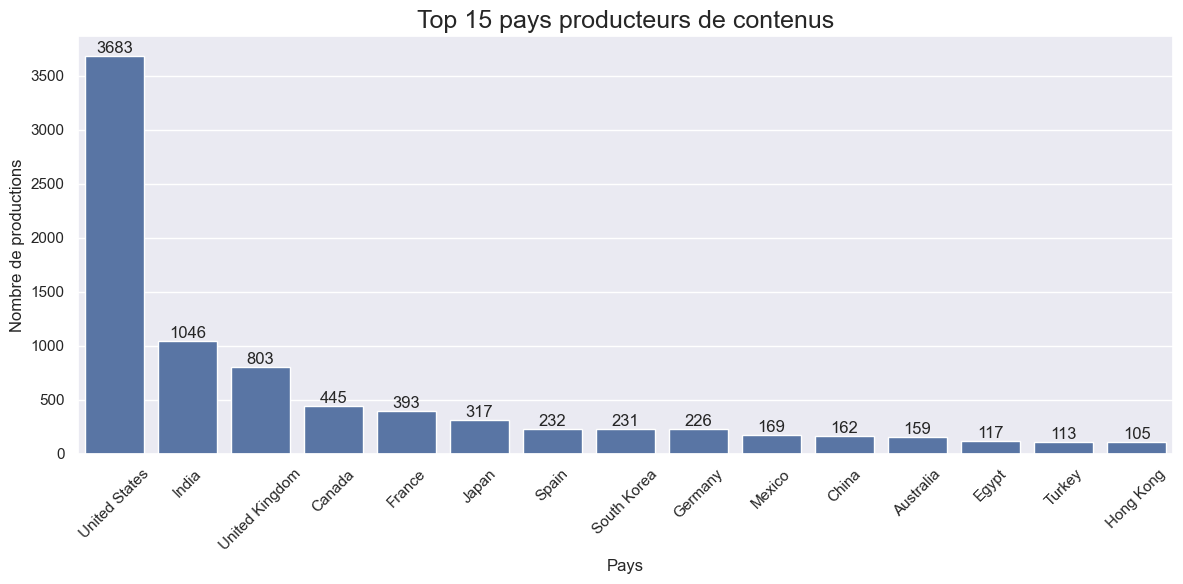

In [9]:
plt.figure(figsize=(12,6))

ax = sns.barplot(
    data=top_countries,
    x="country",
    y="count"
)

plt.title("Top 15 pays producteurs de contenus", fontsize=18)
plt.xlabel("Pays")
plt.ylabel("Nombre de productions")
plt.xticks(rotation=45)

for p in ax.patches:
    height = p.get_height()
    ax.annotate(
        f'{int(height)}',
        (p.get_x() + p.get_width() / 2, height),
        ha='center',
        va='bottom'
    )

del(top_countries,ax,height,p)

plt.tight_layout()
plt.show()

### Les États-Unis dominent largement la production. Cependant, on observe une forte présence de l’Inde et du Royaume-Uni, ce qui montre une stratégie d’expansion internationale.

## Nombre de productions par pays et par classification d’âge (rating)

In [10]:
top_countries = cleaned_df['country'].value_counts().head(10).index
filtered_df = cleaned_df[cleaned_df['country'].isin(top_countries)]

In [11]:
country_rating_pivot = filtered_df.pivot_table(
    index='country',
    columns='rating',
    values='title',
    aggfunc='count',
    fill_value=0
)

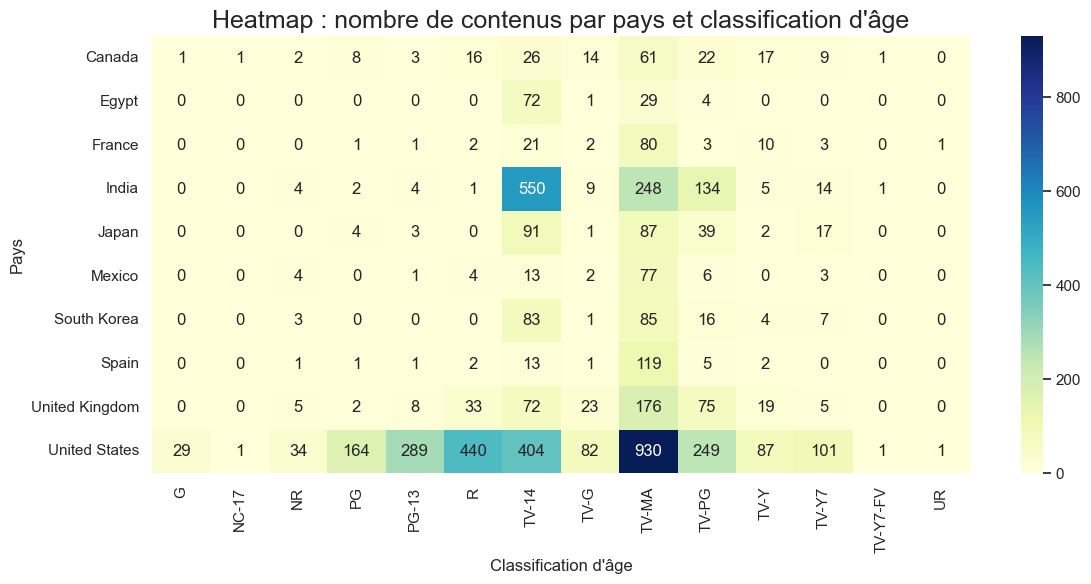

In [12]:
plt.figure(figsize=(12,6))

sns.heatmap(
    country_rating_pivot,
    annot=True,
    fmt='d',
    cmap='YlGnBu'
)

plt.title("Heatmap : nombre de contenus par pays et classification d'âge", fontsize=18)
plt.xlabel("Classification d'âge")
plt.ylabel("Pays")

del(top_countries,filtered_df,country_rating_pivot)

plt.tight_layout()
plt.show()

### Les contenus pour enfants (TV-Y/TV-Y7) sont majoritairement produits aux États-Unis  La plupart des pays, comme l’Inde et au Royaume-Uni, produisent essentiellement des contenus adultes (TV-MA/TV-14/R). Netflix semble adapter ses productions selon le marché local.

## Analyse des genres (listed_in)

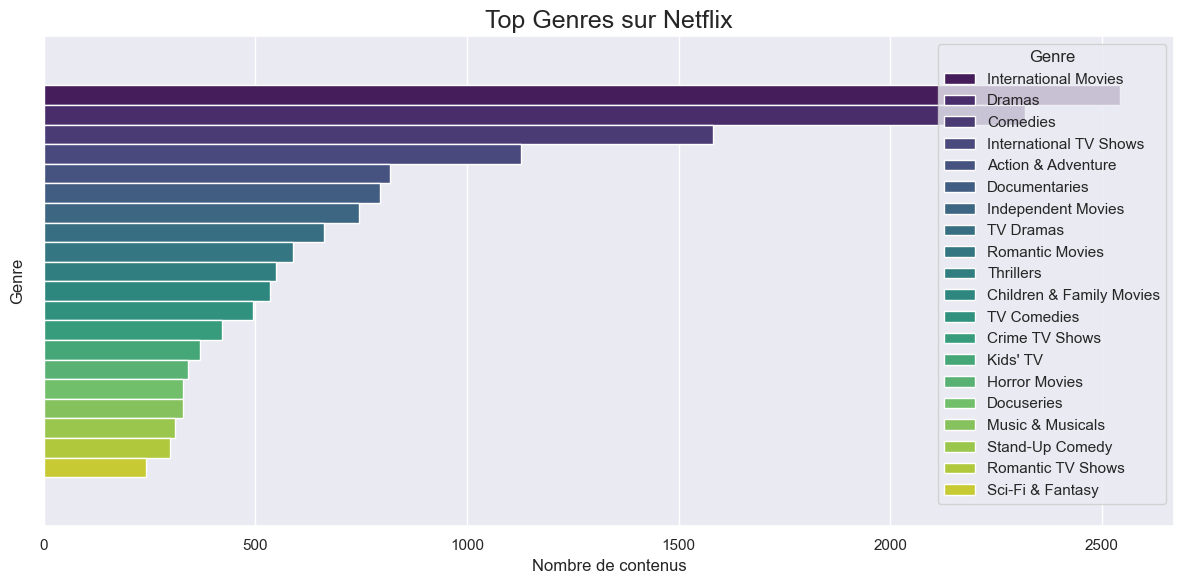

In [13]:
plt.figure(figsize=(12,6))

genre_sorted = genre_pivot_df.sort_values("Count", ascending=False).head(20)

sns.barplot(
    data=genre_sorted,
    x="Count",
    hue="Genre",
    palette="viridis"
)
del(genre_sorted)

plt.title("Top Genres sur Netflix", fontsize=18)
plt.xlabel("Nombre de contenus")
plt.ylabel("Genre")
plt.tight_layout()
plt.show()

### International Movies et Dramas dominent le catalogue.
### Les genres comme Action & Adventure ou Comedies ont une présence moindre mais significative.
### Cela montre que Netflix cible un public varié mais avec une forte priorité sur les films internationaux et les drames.

In [14]:
del(cleaned_df,genre_pivot_df,country_pivot_df)

## ✅ Synthèse globale

Public cible : Majoritairement adultes, contenus enfants à renforcer.

Format : Films dominants, mais séries en forte croissance depuis 2016.

Géographie : États-Unis principaux producteurs, diversification internationale nécessaire.

Genres dominants : International Movies et Dramas, suivi par Comedies et Action.

Stratégie actionnable :

Continuer la croissance des séries originales.

Développer du contenu jeunesse dans les marchés sous-représentés.

Diversifier les genres pour capter de nouvelles audiences.

Planifier les ajouts de contenus pour maintenir l’engagement et l’abonnement.

# Bonus

### Top acteurs par nombre d’apparitions

In [26]:
cast_pivot_df = pd.read_excel("./data/clean_data.xlsx",sheet_name="Cast Pivot")
cast_pivot_df.head()

,cast,count
0,Anupam Kher,43
1,Shah Rukh Khan,34
2,Naseeruddin Shah,31
3,Akshay Kumar,30
4,Om Puri,30


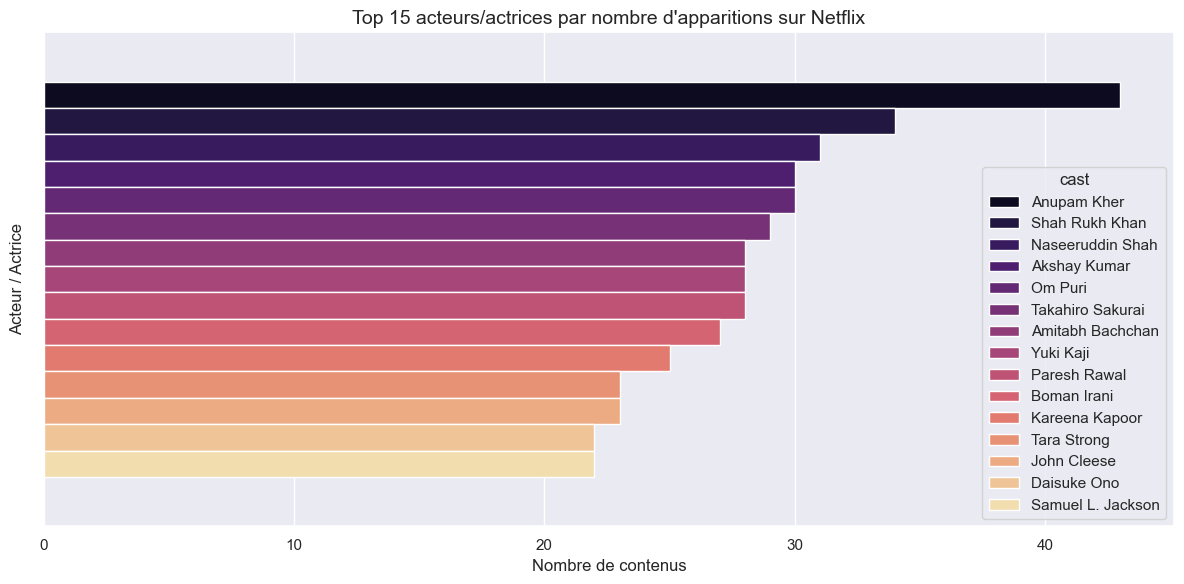

In [27]:

# Trier par nombre d'apparitions et prendre les 15 premiers
top_cast = cast_pivot_df.sort_values("count", ascending=False).head(15)

plt.figure(figsize=(12,6))

sns.barplot(
    x="count",
    hue="cast",
    data=top_cast,
    palette="magma"
)

plt.title("Top 15 acteurs/actrices par nombre d'apparitions sur Netflix", fontsize=14)
plt.xlabel("Nombre de contenus")
plt.ylabel("Acteur / Actrice")
plt.tight_layout()
plt.show()

In [28]:
del(cast_pivot_df,top_cast)